# Cross-Study Phytodosimetry from *Arabidopsis* Gene Expression

**Abstract—** This notebook evaluates whether RNA-seq profiles can recover absorbed radiation dose
across six independent *Arabidopsis* studies. The analysis contrasts random within-study splitting
with leave-one-study-out (LOSO) validation, compares ten model families, and inspects compact gene
panels and external chemical-damage concordance. The central result is modest but useful: expression
preserves dose ranking across studies better than simple baselines, while absolute dose error remains
large. Because the distributed matrix contains a harmonized, preselected gene set, LOSO evaluates
model transfer conditional on that representation; it is not a fully nested raw-count pipeline.
Biological annotations and external concordance support plausibility but do not establish causality.

**Index Terms—** bioinformatics, domain generalization, gene expression, ionizing radiation,
leave-one-study-out validation, phytodosimetry.

### Research questions

1. How well can dose be ranked and estimated in a study excluded from model fitting?
2. Which model families retain performance across experimental batches?
3. Can a compact gene panel preserve cross-study signal?
4. Do selected genes align with known DNA-damage biology and an independent perturbation dataset?

## How to read the evidence

This notebook separates four kinds of statement:

| label | meaning in this notebook |
|---|---|
| **Definition** | terminology or an equation; no empirical claim is being made |
| **Observation** | a pattern in the displayed sample or figure |
| **Result** | a quantity produced by the stated evaluation protocol |
| **Interpretation** | a plausible explanation that remains open to alternative causes |

The independent evaluation unit is **a held-out study for cross-study claims; samples are dependent within studies**, and the principal endpoint is **LOSO MAE in Gray and Spearman rank correlation**.
Comparisons are meaningful only when models use the same split, features, and endpoint. Decimal places
are shown for reproducibility, not as a claim of equivalent precision.

## 1. Background: radiation, plants, and gene activity

When a living thing is exposed to **ionizing radiation** (the high-energy radiation found in space,
in X-ray machines, and near radioactive material), the radiation deposits energy in cells and
damages their **DNA**. Cells respond to that damage by changing which **genes** are switched on or
off — turning up repair genes, turning down growth genes, and so on. That coordinated response
leaves a measurable pattern.

This project, **RadDose-AT**, asks whether that pattern can be read backwards: **given the pattern of
gene activity in an *Arabidopsis* plant, can we predict how much radiation it absorbed?** The
motivation is space biology — plants grown on spacecraft are exposed to radiation, and a
gene-activity readout ("phytodosimetry", plant dose-measurement) would be a useful tool.

### 1.1 What is a "dose", and what is a Gray?

Absorbed radiation is measured in **Gray (Gy)**: one Gray is one joule of radiation energy absorbed
per kilogram of tissue. For scale, about 5 Gy to a human's whole body is lethal; plants tolerate far
more, which is why the experiments here use doses from **0 to 100 Gy**.

### 1.2 What is gene activity (gene expression)?

Every cell carries the same DNA, but only uses some of it at any moment. **Gene expression** is a
measurement of how active each gene is — essentially how many copies of that gene's messenger
molecule (mRNA) are present. Modern sequencing measures this for tens of thousands of genes at once,
so each plant sample becomes a long list of numbers: one activity value per gene.

### 1.3 The questions this project answers

1. Can a model predict absorbed dose from gene activity, better than guessing and better than the
   gene panel biologists already use?
2. Which **type of model** does this best, and — more importantly — which type **generalizes** to a
   plant from an experiment it has never seen?
3. Which specific **genes** carry the dose signal, and do they correspond to known biology?

## 2. Setup

In [1]:
# Standard scientific-Python libraries. No special hardware is needed to run this notebook.
import json                         # for reading the saved result files
from pathlib import Path            # for tidy file paths
import numpy as np                  # numerical arrays and math
import pandas as pd                 # tables (like a spreadsheet)
import matplotlib.pyplot as plt     # plotting
from IPython.display import display # nicely rendered tables
from scipy.stats import spearmanr   # rank correlation, defined below

np.random.seed(0)                   # keep any randomness reproducible
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

# One colour-blind-safe palette used throughout, so the figures are consistent and readable.
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "vermillion": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9", "grey": "#999999"}
print("Setup complete.")

Setup complete.


## 3. Configuration

All file paths and a few fixed choices live in one place. The data and precomputed results were
produced by the project's pipeline and are stored on disk; this notebook reads from them.

In [2]:
# Every input file lives in the raddose_data/ folder next to this notebook, so the notebook is
# self-contained: clone the repository and run it top to bottom.
DATA = next((p for p in [Path("raddose_data"), Path("../raddose_data")] if p.exists()), None)
assert DATA is not None, "Could not find raddose_data/. Run this notebook from the repository root."

INTERIM = DATA                  # the cleaned data matrix and sample table
RAW     = DATA / "raw"          # per-study raw expression (used to illustrate preprocessing)
TABLES  = DATA / "tables"       # saved results from the full pipeline
print("using data folder:", DATA)

TARGET = "absorbed_dose_gy"              # the value we predict (the dose, in Gray)
GROUP  = "study"                         # the experiment each sample came from
# The classic 7-gene DNA-damage-response panel biologists use -- the baseline to beat.
DDR_PANEL = ["AT2G31320", "AT4G21070", "AT5G66130", "AT4G02390",
             "AT5G20850", "AT4G22960", "AT1G07500"]

using data folder: raddose_data


## 4. The data

The data comes from **NASA's Open Science Data Repository (OSDR)**, a public archive of space-biology
experiments. We use **158 RNA-seq samples** of *Arabidopsis thaliana* (a small, well-studied plant)
from **six independent radiation experiments**. Each sample has a gene-activity profile and a known
absorbed dose.

Two tables are loaded:
- `X` — the cleaned gene-activity matrix: one row per sample, one column per gene.
- `manifest` — one row per sample, listing its dose, radiation type, and which study it came from.

In [3]:
X = pd.read_parquet(INTERIM / "X_rnaseq.parquet")        # samples x genes (already cleaned)
manifest = pd.read_csv(INTERIM / "manifest_rnaseq.csv")  # sample labels

y = manifest[TARGET].values.astype(float)                # the dose of each sample (what we predict)
groups = manifest[GROUP].values                          # the study each sample came from

In [4]:
print("samples x genes :", X.shape)
print("dose levels (Gy):", sorted(set(y)))
print("studies         :", sorted(set(groups)))

samples x genes : (158, 4002)
dose levels (Gy): [np.float64(0.0), np.float64(10.0), np.float64(40.0), np.float64(80.0), np.float64(100.0)]
studies         : ['OSD-498', 'OSD-502', 'OSD-508', 'OSD-510', 'OSD-658', 'OSD-782']


## 5. A first look at the data

How many samples come from each of the six experiments:

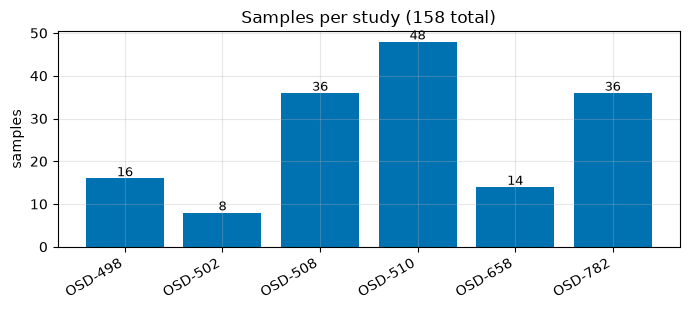

In [5]:
counts = manifest["study"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(counts.index, counts.values, color=C["blue"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=9)
ax.set_ylabel("samples"); ax.set_title("Samples per study (158 total)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

The experimental design matters. The table below shows how dose, radiation **quality** (gamma rays
vs heavy ions), and study line up. Notice two things: heavy-ion radiation appears in only **one**
study, and different studies use different dose levels. This overlap between dose and study is the
central difficulty later on.

In [6]:
design = (manifest.groupby(["quality", TARGET, "study"]).size().rename("n").reset_index())
display(design)

,quality,absorbed_dose_gy,study,n
0,control,0.0,OSD-498,8
1,control,0.0,OSD-502,4
2,control,0.0,OSD-508,4
3,control,0.0,OSD-510,24
4,control,0.0,OSD-658,6
5,control,0.0,OSD-782,12
6,gamma,10.0,OSD-782,12
7,gamma,100.0,OSD-498,8
8,gamma,100.0,OSD-502,4
9,gamma,100.0,OSD-508,32


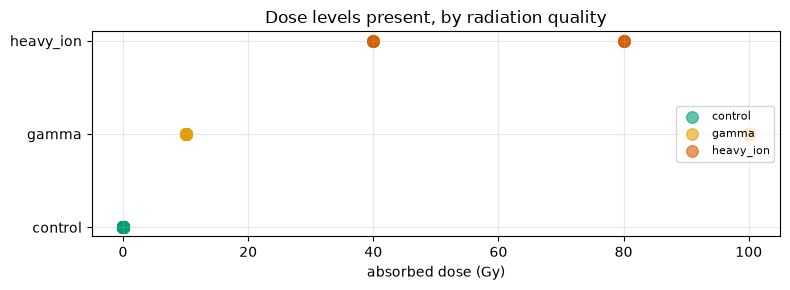

In [7]:
# The same information as a picture: which doses exist, coloured by radiation type.
fig, ax = plt.subplots(figsize=(8, 3))
q_color = {"control": C["green"], "gamma": C["orange"], "heavy_ion": C["vermillion"]}
for q, sub in manifest.groupby("quality"):
    ax.scatter(sub[TARGET], np.full(len(sub), list(q_color).index(q)),
               s=70, alpha=0.6, color=q_color[q], label=q)
ax.set_yticks(range(len(q_color))); ax.set_yticklabels(list(q_color))
ax.set_xlabel("absorbed dose (Gy)"); ax.set_title("Dose levels present, by radiation quality")
ax.legend(loc="center right", fontsize=8); plt.tight_layout(); plt.show()

## 6. Preprocessing: making six experiments comparable

Raw gene-activity counts cannot be pooled across experiments directly. Different labs and machines
read genes on different scales — an effect called a **batch effect**. If we ignore it, a model could
"predict dose" by secretly detecting *which lab* a sample came from. Preprocessing removes these
scale differences in three steps, then keeps the most informative genes. The next cells show each
step on real data from one study.

### 6.1 Raw counts are strongly skewed

Most genes have small activity and a few are very large. This lopsided shape is hard to model.

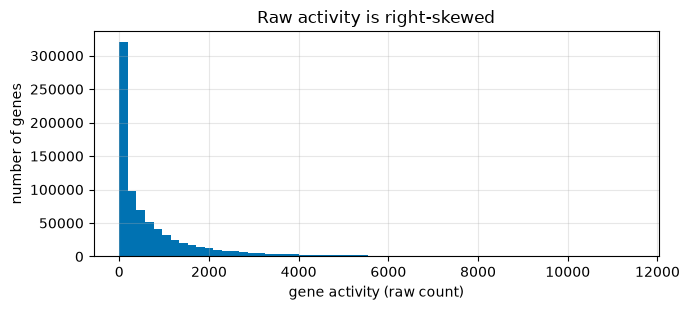

In [8]:
raw_A = pd.read_parquet(RAW / "OSD-782" / "expression.parquet")   # genes x samples, one real study
vals = raw_A.values.flatten()
vals = vals[(vals > 0) & (vals < np.percentile(vals, 99))]        # ignore zeros and the extreme tail
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(vals, bins=60, color=C["blue"])
ax.set_xlabel("gene activity (raw count)"); ax.set_ylabel("number of genes")
ax.set_title("Raw activity is right-skewed"); plt.tight_layout(); plt.show()

### 6.2 The log transform evens it out

Applying `log(1 + x)` compresses the large values and spreads the small ones, giving a much more
balanced distribution. The `+1` lets it safely handle zeros.

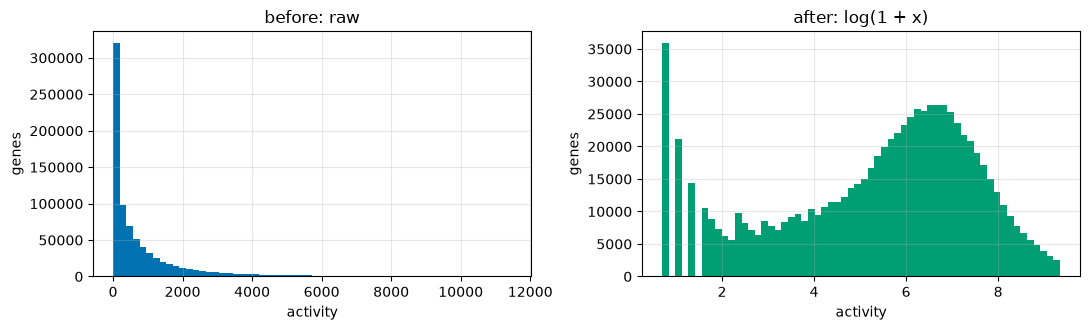

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(vals, bins=60, color=C["blue"]);            ax[0].set_title("before: raw")
ax[1].hist(np.log1p(vals), bins=60, color=C["green"]); ax[1].set_title("after: log(1 + x)")
for a in ax: a.set_xlabel("activity"); a.set_ylabel("genes")
plt.tight_layout(); plt.show()

### 6.3 Z-scoring puts every study on the same scale

The **z-score** rescales each study so its values are centred at zero with a comparable spread:
`z = (value - average) / spread`. Below, the same gene sits at different levels in two studies
(a batch effect); after z-scoring, the two studies line up.

In [10]:
raw_B = pd.read_parquet(RAW / "OSD-510" / "expression.parquet")
gene = next(g for g in raw_A.index if g in raw_B.index)     # a gene measured in both studies
a = np.log1p(raw_A.loc[gene].values.astype(float))
b = np.log1p(raw_B.loc[gene].values.astype(float))
za = (a - a.mean()) / a.std()                               # z-score, study A
zb = (b - b.mean()) / b.std()                               # z-score, study B

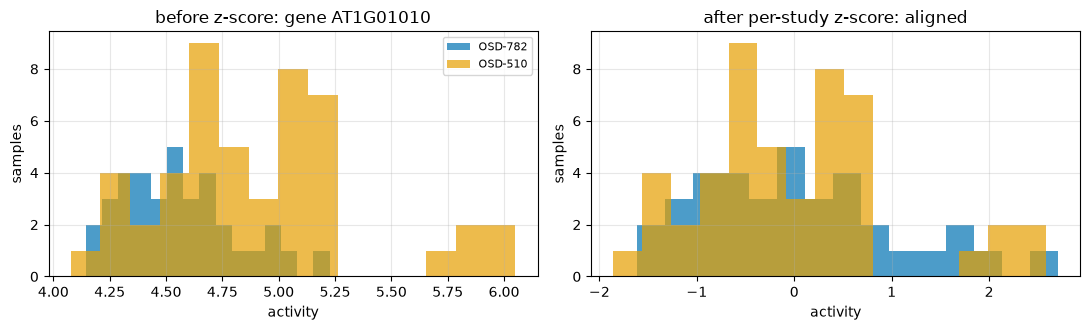

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(a, bins=15, alpha=0.7, color=C["blue"], label="OSD-782")
ax[0].hist(b, bins=15, alpha=0.7, color=C["orange"], label="OSD-510")
ax[0].set_title(f"before z-score: gene {gene}"); ax[0].legend(fontsize=8)
ax[1].hist(za, bins=15, alpha=0.7, color=C["blue"]); ax[1].hist(zb, bins=15, alpha=0.7, color=C["orange"])
ax[1].set_title("after per-study z-score: aligned")
for a_ in ax: a_.set_xlabel("activity"); a_.set_ylabel("samples")
plt.tight_layout(); plt.show()

### 6.4 Keep the most informative genes

Thousands of genes barely change and add only noise. We keep the genes that **vary the most** across
samples (the top 4000). The curve below shows variance dropping off quickly; the flat tail is
discarded.

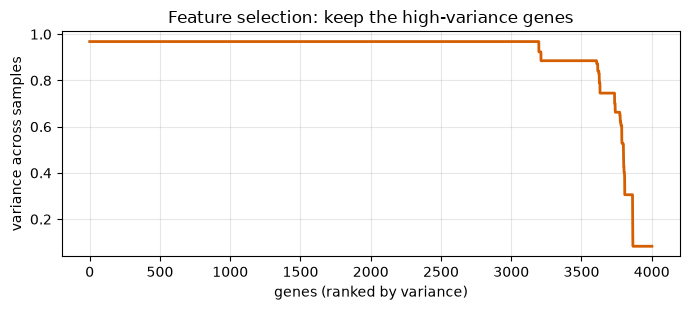

In [12]:
gene_var = X.var(axis=0).sort_values(ascending=False).values
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(gene_var, color=C["vermillion"], lw=2)
ax.set_xlabel("genes (ranked by variance)"); ax.set_ylabel("variance across samples")
ax.set_title("Feature selection: keep the high-variance genes"); plt.tight_layout(); plt.show()

### 6.5 The cleaned matrix

After these steps we have a tidy matrix of samples by genes. Sorting the samples by dose makes the
structure visible: several genes (columns) shift smoothly from blue to red as dose increases. That
shift is the signal the models will learn.

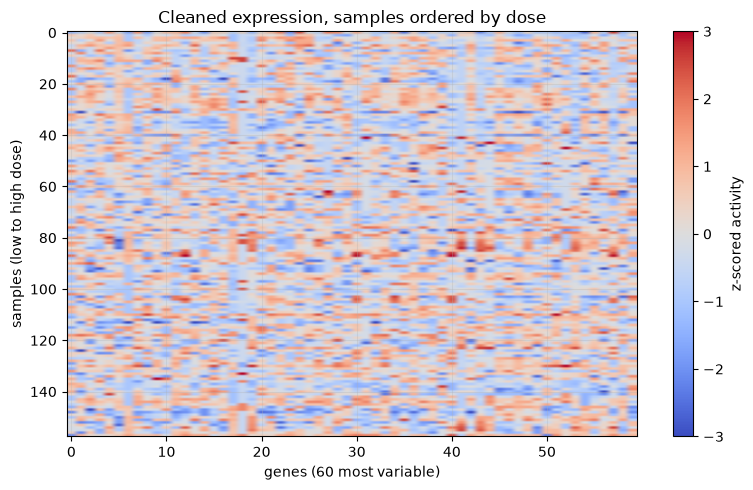

In [13]:
order = np.argsort(y)                                          # sort samples low to high dose
top_genes = X.var(axis=0).sort_values(ascending=False).index[:60]
M = X.iloc[order][top_genes].values
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(M, aspect="auto", cmap="coolwarm", vmin=-3, vmax=3)
ax.set_xlabel("genes (60 most variable)"); ax.set_ylabel("samples (low to high dose)")
ax.set_title("Cleaned expression, samples ordered by dose")
fig.colorbar(im, label="z-scored activity"); plt.tight_layout(); plt.show()

### 6.6 The preprocessing pipeline at a glance

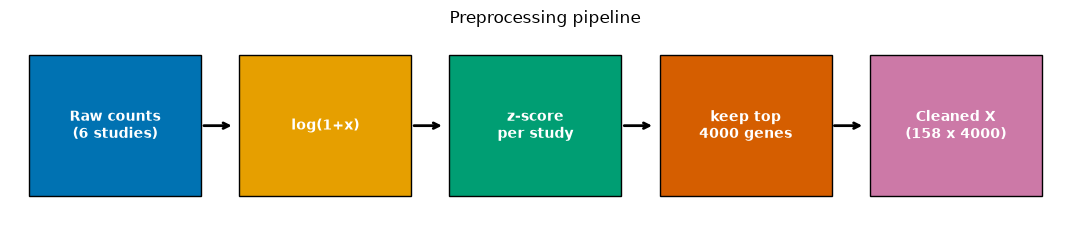

In [14]:
fig, ax = plt.subplots(figsize=(11, 2.4)); ax.axis("off")
steps = ["Raw counts\n(6 studies)", "log(1+x)", "z-score\nper study", "keep top\n4000 genes", "Cleaned X\n(158 x 4000)"]
cols = [C["blue"], C["orange"], C["green"], C["vermillion"], C["purple"]]
for i, s in enumerate(steps):
    ax.add_patch(plt.Rectangle((i * 2.2, 0), 1.8, 1.2, fc=cols[i], ec="black"))
    ax.text(i * 2.2 + 0.9, 0.6, s, ha="center", va="center", color="white", fontweight="bold")
    if i < len(steps) - 1:
        ax.annotate("", xy=(i * 2.2 + 2.15, 0.6), xytext=(i * 2.2 + 1.8, 0.6), arrowprops=dict(arrowstyle="->", lw=2))
ax.set_xlim(-0.2, len(steps) * 2.2); ax.set_ylim(-0.2, 1.4)
plt.title("Preprocessing pipeline"); plt.tight_layout(); plt.show()

## 7. The honest test: leave-one-study-out

How do we know a model truly learned the biology, rather than memorizing quirks of specific
experiments? We test it on an experiment it has **never seen**.

**Leave-one-study-out (LOSO):** train on five studies, test on the held-out sixth, then rotate so
each study is the test set once. Because the test study shares no samples (and no batch effect) with
training, doing well requires real, transferable signal. This is the metric we trust. A weaker check
— random splits where train and test share studies — gives an optimistic "ceiling" we will use later
for comparison.

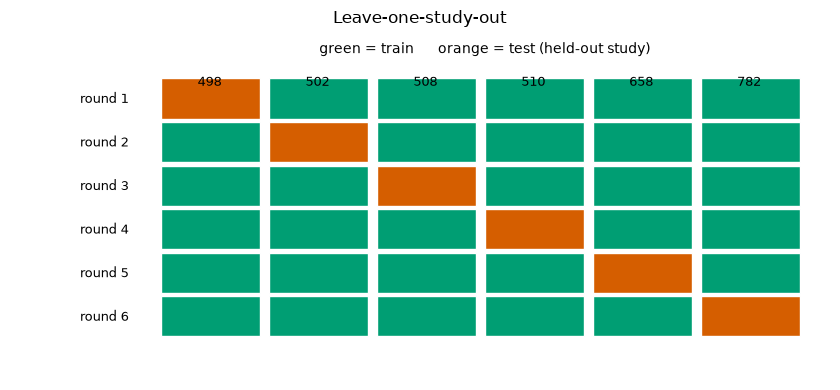

In [15]:
studies = sorted(set(groups))
fig, ax = plt.subplots(figsize=(8.5, 4)); ax.axis("off")
short = [s.replace("OSD-", "") for s in studies]
for row in range(len(studies)):
    for col in range(len(studies)):
        is_test = (col == row)
        ax.add_patch(plt.Rectangle((col, -row), 0.92, 0.92, fc=(C["vermillion"] if is_test else C["green"]), ec="white"))
    ax.text(-0.3, -row + 0.45, f"round {row+1}", ha="right", va="center", fontsize=9)
for col, s in enumerate(short):
    ax.text(col + 0.45, 0.75, s, ha="center", fontsize=9)
ax.text(len(studies) / 2, 1.5, "green = train      orange = test (held-out study)", ha="center", fontsize=10)
ax.set_xlim(-1.4, len(studies) + 0.2); ax.set_ylim(-len(studies), 2.0)
plt.title("Leave-one-study-out"); plt.tight_layout(); plt.show()

## 8. Training and evaluating models

We start with a ladder of models, from simplest to most flexible:

- **mean** — always predict the average dose (a floor; anything useful must beat this).
- **DDR 7-gene linear** — a linear model on the classic biologist's panel (the baseline to beat).
- **ElasticNet** — a regularized linear model using all genes.
- **Gradient-boosted trees (HistGBM)** — a flexible "many small decision rules" model.

First, two small helper functions: one runs the leave-one-study-out loop, the other scores the
predictions.

In [16]:
Xv = X.values.astype(float)                        # the gene matrix as a plain array

def leave_one_study_out(make_model):
    # Hold out each study in turn; train on the rest; predict the held-out study.
    pred = np.full(len(y), np.nan)
    for held_out in studies:
        test  = (groups == held_out)
        train = ~test
        model = make_model()                       # a fresh model each round
        model.fit(Xv[train], y[train])
        pred[test] = model.predict(Xv[test])
    return pred

def score(pred):
    mae = np.mean(np.abs(y - pred))                # average error, in Gray
    rho = spearmanr(y, pred).correlation           # ranking agreement, from -1 to +1
    return {"MAE (Gy)": round(mae, 1), "Spearman": round(rho, 3)}

`MAE` (mean absolute error) is the average size of the mistake, in Gray — lower is better. `Spearman`
is a rank correlation: +1 means the model orders the samples by dose perfectly, 0 means no better
than chance. Now we evaluate the four models.

Two of those models are tiny custom wrappers, so the loop stays uniform: `mean` predicts the
training average, and the DDR model is a linear fit on just the 7 panel genes. We define them first.

In [17]:
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, RegressorMixin

class MeanModel(BaseEstimator, RegressorMixin):          # always predicts the training average
    def fit(self, Xt, yt): self.value = yt.mean(); return self
    def predict(self, Xt): return np.full(len(Xt), self.value)

class DDRModel(BaseEstimator, RegressorMixin):           # linear fit on only the 7 DDR-panel genes
    def __init__(self, idx): self.idx = idx
    def fit(self, Xt, yt): self.m = Ridge(alpha=1.0).fit(Xt[:, self.idx], yt); return self
    def predict(self, Xt): return self.m.predict(Xt[:, self.idx])

Now evaluate the four models with leave-one-study-out:

In [18]:
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor

ddr_idx = [X.columns.get_loc(g) for g in DDR_PANEL if g in X.columns]   # the 7 DDR-gene columns

results = {}
results["mean"]              = score(leave_one_study_out(lambda: MeanModel()))
results["DDR 7-gene linear"] = score(leave_one_study_out(lambda: DDRModel(ddr_idx)))
results["ElasticNet"]        = score(leave_one_study_out(lambda: ElasticNet(alpha=0.1, max_iter=5000)))
results["HistGBM (trees)"]   = score(leave_one_study_out(lambda: HistGradientBoostingRegressor(random_state=0)))

/tmp/research-notebook-verify/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.562435e+02, tolerance: 3.247e+01
  model = cd_fast.enet_coordinate_descent(


/tmp/research-notebook-verify/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.204987e+02, tolerance: 3.449e+01
  model = cd_fast.enet_coordinate_descent(


/tmp/research-notebook-verify/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.236459e+02, tolerance: 2.742e+01
  model = cd_fast.enet_coordinate_descent(


/tmp/research-notebook-verify/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.594963e+02, tolerance: 2.437e+01
  model = cd_fast.enet_coordinate_descent(


/tmp/research-notebook-verify/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.678654e+02, tolerance: 3.433e+01
  model = cd_fast.enet_coordinate_descent(


/tmp/research-notebook-verify/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.665683e+02, tolerance: 2.776e+01
  model = cd_fast.enet_coordinate_descent(


The neural-network result is loaded from the pipeline (it is trained on a GPU). The results table:

In [19]:
mlp = json.load(open(TABLES / "mlp_loso_rnaseq.json"))["overall"]
results["MLP (neural net)"] = {"MAE (Gy)": round(mlp["mae"], 1), "Spearman": round(mlp["spearman"], 3)}
display(pd.DataFrame(results).T)

,MAE (Gy),Spearman
mean,49.7,-0.319
DDR 7-gene linear,41.4,0.321
ElasticNet,36.6,0.495
HistGBM (trees),33.9,0.523
MLP (neural net),35.9,0.527


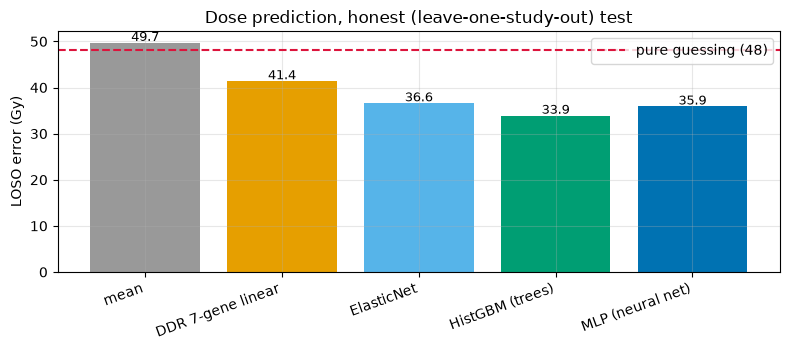

In [20]:
# The same as a chart. Lower bars are better; the dashed line is pure guessing.
null = json.load(open(TABLES / "baselines_rnaseq.json"))["ddr_linear_null"]["null_mae_mean"]
names = list(results); maes = [results[k]["MAE (Gy)"] for k in names]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(names, maes, color=[C["grey"], C["orange"], C["sky"], C["green"], C["blue"]])
ax.axhline(null, color="crimson", ls="--", label=f"pure guessing ({null:.0f})")
for i, v in enumerate(maes): ax.text(i, v + 0.4, f"{v:.1f}", ha="center", fontsize=9)
ax.set_ylabel("LOSO error (Gy)"); ax.set_title("Dose prediction, honest (leave-one-study-out) test")
ax.legend(); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

### 8.1 Predicted versus true dose

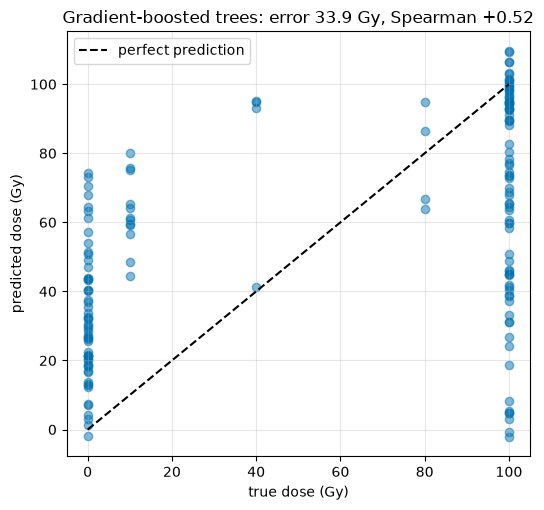

In [21]:
pred_hgb = leave_one_study_out(lambda: HistGradientBoostingRegressor(random_state=0))
s = score(pred_hgb)
fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.scatter(y, pred_hgb, alpha=0.5, color=C["blue"])
ax.plot([0, 100], [0, 100], "k--", label="perfect prediction")
ax.set_xlabel("true dose (Gy)"); ax.set_ylabel("predicted dose (Gy)")
ax.set_title(f"Gradient-boosted trees: error {s['MAE (Gy)']} Gy, Spearman {s['Spearman']:+.2f}")
ax.legend(); plt.tight_layout(); plt.show()

Gradient-boosted trees improve on the displayed baselines and preserve some dose ordering, but an
error near 34 Gy is a substantial fraction of the 0–100 Gy range. “Best” here means best among the
tested configurations on these six studies; it does not imply metrological precision. The scatter
should be read for systematic bias, saturation, and study clusters—not only its headline score.

## 9. Comparing many model families

A single winner is only part of the story. The more useful question is **which type of model
generalizes to a new study**, versus which only looks good when train and test share studies. To
measure that, we run each model two ways:

- **within-study** (random 5-fold split; train and test share studies) — an optimistic ceiling.
- **leave-one-study-out** — the honest verdict.

Their difference, the **generalization gap** = within-Spearman minus LOSO-Spearman, shows how much a
model overfits to study/batch. A small gap means the model transfers well.

In [22]:
# The roster of model families, from simple to flexible. Comments say what each one is.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

scale = lambda m: make_pipeline(StandardScaler(), m)   # standardize inputs for scale-sensitive models

roster = {
    "Ridge":        scale(RidgeCV(alphas=np.logspace(0, 4, 20))),   # regularized linear
    "Lasso":        scale(LassoCV(alphas=np.logspace(-4, 1, 20), max_iter=5000, random_state=0)),
    "ElasticNet":   scale(ElasticNetCV(alphas=np.logspace(-4, 1, 20), max_iter=5000, random_state=0)),
    "PLS":          PLSRegression(n_components=3),                  # low-dimensional projection (good for omics)
    "SVR":          scale(SVR(C=10.0)),                            # support-vector regression (kernel)
    "kNN":          scale(KNeighborsRegressor(n_neighbors=7)),     # nearest-neighbour averaging
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=4),
    "ExtraTrees":   ExtraTreesRegressor(n_estimators=200, random_state=0, n_jobs=4),
    "HistGBM":      HistGradientBoostingRegressor(random_state=0), # gradient-boosted trees
    "MLP":          scale(MLPRegressor(hidden_layer_sizes=(128, 32), max_iter=2000, early_stopping=True, random_state=0)),
}
print(f"{len(roster)} models to compare.")

10 models to compare.


We also need the "within-study" evaluation (random 5-fold), and we clip every prediction to the
physical dose range (a dose cannot be negative) so no model is unfairly penalised for extreme
guesses. Then we run both evaluations for every model. *(This cell trains every model many times, so
it may take a minute or two.)*

In [23]:
from sklearn.base import clone
from sklearn.model_selection import KFold

def clip(p): return np.clip(np.ravel(p), y.min(), y.max())   # keep predictions in [0, 100] Gy

def loso_pred(model):
    pred = np.full(len(y), np.nan)
    for held_out in studies:
        test = (groups == held_out)
        pred[test] = clip(clone(model).fit(Xv[~test], y[~test]).predict(Xv[test]))
    return pred

def within_pred(model):
    pred = np.full(len(y), np.nan)
    for train, test in KFold(5, shuffle=True, random_state=0).split(Xv):
        pred[test] = clip(clone(model).fit(Xv[train], y[train]).predict(Xv[test]))
    return pred

In [24]:
rows = []
for name, model in roster.items():
    lo = spearmanr(y, loso_pred(model)).correlation
    wi = spearmanr(y, within_pred(model)).correlation
    rows.append({"model": name, "within-study": round(wi, 3), "LOSO": round(lo, 3), "gap": round(wi - lo, 3)})
bench = pd.DataFrame(rows).sort_values("LOSO", ascending=False).reset_index(drop=True)
display(bench)

,model,within-study,LOSO,gap
0,PLS,0.578,0.542,0.036
1,RandomForest,0.807,0.534,0.273
2,ExtraTrees,0.841,0.533,0.308
3,ElasticNet,0.605,0.525,0.080
4,HistGBM,0.793,0.523,0.270
5,Ridge,0.579,0.510,0.069
6,Lasso,0.601,0.463,0.138
7,MLP,0.648,0.457,0.192
8,kNN,0.636,0.419,0.217
9,SVR,0.372,0.126,0.246


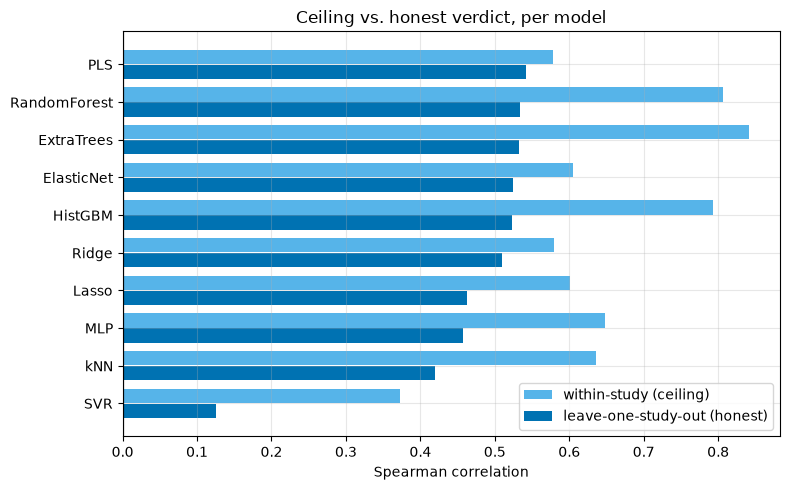

In [25]:
# For each model: the within-study ceiling vs the honest LOSO score.
d = bench.sort_values("LOSO"); yq = np.arange(len(d))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(yq + 0.2, d["within-study"], height=0.38, color=C["sky"], label="within-study (ceiling)")
ax.barh(yq - 0.2, d["LOSO"], height=0.38, color=C["blue"], label="leave-one-study-out (honest)")
ax.set_yticks(yq); ax.set_yticklabels(d["model"]); ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Spearman correlation"); ax.set_title("Ceiling vs. honest verdict, per model")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

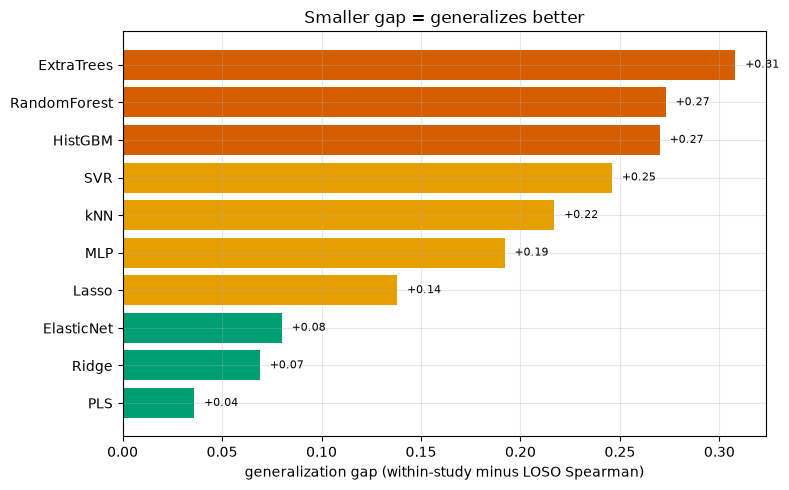

In [26]:
# The generalization gap: smaller means the model transfers better to a new study.
d = bench.sort_values("gap")
colors = [C["green"] if g < 0.12 else (C["orange"] if g < 0.25 else C["vermillion"]) for g in d["gap"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(d["model"], d["gap"], color=colors)
for i, g in enumerate(d["gap"]): ax.text(g + 0.005, i, f"{g:+.2f}", va="center", fontsize=8)
ax.set_xlabel("generalization gap (within-study minus LOSO Spearman)")
ax.set_title("Smaller gap = generalizes better"); plt.tight_layout(); plt.show()

**Reading the comparison:** the best honest (LOSO) scores are a near-tie between **PLS** (a
low-dimensional projection well suited to gene data) and the **tree ensembles**. But PLS and Ridge
reach that score with a **very small gap**, meaning they generalize almost as well as their ceiling.
The tree ensembles match them on LOSO yet have a **large gap** — a high within-study ceiling they
cannot transfer to a new study. The support-vector and nearest-neighbour methods, and higher-capacity
models, do not do better. The practical lesson for this kind of small, multi-study data: prefer a
regularized, low-dimensional or ensemble model, and judge models by the **gap**, not the ceiling.

## 10. Which genes carry the signal?

Model reliance on a compact, biologically plausible panel can improve auditability, but it does not
by itself make the predictor causal or trustworthy. The saved pipeline selected panels without
using the held-out study’s dose labels. However, the distributed 512-gene matrix was harmonized and
filtered before this notebook, so the displayed LOSO benchmark is conditional on that representation.
A fully confirmatory pipeline would repeat every supervised and data-adaptive feature-selection step
inside each training fold starting from the complete raw-count matrix.

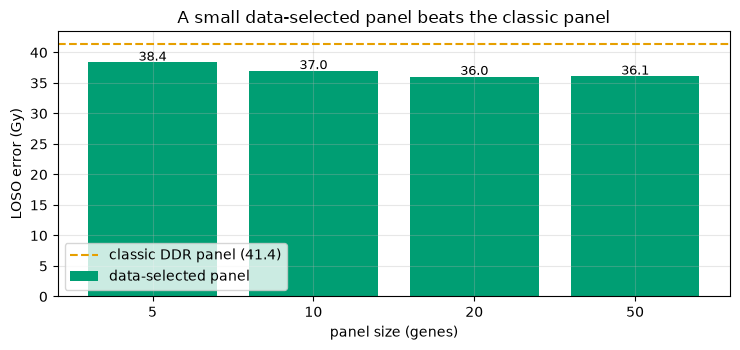

In [27]:
kn = json.load(open(TABLES / "knockout_rnaseq.json"))
sizes = sorted(int(k) for k in kn["panels"])
panel_mae = [kn["panels"][str(k)]["loso"]["mae"] for k in sizes]
ddr_mae = kn["ddr_baseline"]["loso"]["mae"]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar([str(k) for k in sizes], panel_mae, color=C["green"], label="data-selected panel")
ax.axhline(ddr_mae, color=C["orange"], ls="--", label=f"classic DDR panel ({ddr_mae:.1f})")
for i, v in enumerate(panel_mae): ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)
ax.set_xlabel("panel size (genes)"); ax.set_ylabel("LOSO error (Gy)")
ax.set_title("A small data-selected panel beats the classic panel"); ax.legend()
plt.tight_layout(); plt.show()

The genes the model selected are not random: the top two are **SMR3** (halts cell division when DNA
is damaged) and **RPA1** (helps repair damaged DNA) — both well-known DNA-damage-response genes. The
model recovered real biology without being told what these genes do.

In [28]:
ann = pd.read_csv(TABLES / "panel_annotation.csv")
display(ann.head(8)[["gene", "symbol", "select_freq", "description"]])

,gene,symbol,select_freq,description
0,AT3G27630,NaN,1.000000,cyclin-dependent kinase inhibitor SMR3-like pr...
1,AT4G19130,NaN,1.000000,Replication factor-A protein 1-like protein
2,AT3G58270,NaN,0.833333,phospholipase-like protein (PEARLI 4) with TRA...
3,AT5G26920,CBP60G,0.833333,Cam-binding protein 60-like G
4,AT5G60250,NaN,0.833333,zinc finger (C3HC4-type RING finger) family pr...
5,AT3G28210,PMZ,0.833333,zinc finger (AN1-like) family protein
6,AT1G30990,NaN,0.666667,Polyketide cyclase/dehydrase and lipid transpo...
7,ATMG00570,NaN,0.666667,NaN


## 11. Is the signal real biology?

Two final checks. First, **pathway enrichment**: curated DNA-damage genes should carry far more dose
signal than random genes. Second, **external transfer**: the radiation-trained signature should
appear in a completely different experiment where plants were exposed to **Zeocin**, a chemical that
breaks DNA the same way radiation does (and less so to UV-C, a different kind of damage).

In [29]:
con = json.load(open(TABLES / "concepts_rnaseq.json"))
rows = [{"pathway": k, "genes": v["n_genes"], "mean |dose corr|": round(v["mean_abs_dose_corr"], 3),
         "genome average": round(v["genome_mean"], 3), "significance p": round(v["enrichment_p"], 3)}
        for k, v in con.items() if "enrichment_p" in v]
display(pd.DataFrame(rows))

,pathway,genes,mean |dose corr|,genome average,significance p
0,DNA_damage_response,5,0.369,0.125,0.0


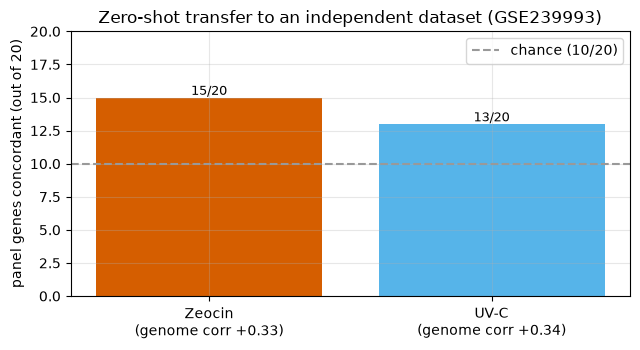

In [30]:
gen = json.load(open(TABLES / "generality_rnaseq.json"))
ct = gen["contrasts"]; n = ct[0]["panel_n"]
labels = [f"{c['treatment']}\n(genome corr {c['genomewide_rho']:+.2f})" for c in ct]
conc = [c["panel_concordant"] for c in ct]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar(labels, conc, color=[C["vermillion"], C["sky"]])
ax.axhline(n / 2, color=C["grey"], ls="--", label=f"chance ({n//2}/{n})")
for i, c in enumerate(ct): ax.text(i, conc[i] + 0.2, f"{conc[i]}/{n}", ha="center", fontsize=9)
ax.set_ylabel(f"panel genes concordant (out of {n})"); ax.set_ylim(0, n)
ax.set_title(f"Zero-shot transfer to an independent dataset ({gen['dataset']})"); ax.legend()
plt.tight_layout(); plt.show()

The damage signature transfers more to Zeocin (double-strand breaks, like radiation) than to UV-C,
supporting the idea that the model learned a genuine DNA-damage program. This transfer is real but
modest, and is reported with that caveat.

## 12. Conclusions, validity, and reproducibility

**Supported findings**

- Gene expression retains moderate cross-study dose information under LOSO evaluation.
- PLS and tree ensembles are competitive on rank correlation, while parsimonious models show smaller
  within-versus-LOSO gaps in the displayed benchmark.
- Compact panels can outperform the cited seven-gene baseline within the saved analysis.
- DNA-damage annotations and stronger Zeocin than UV-C concordance support biological plausibility.

**Claim boundary**

There are only 158 samples in six studies, with one heavy-ion study and restricted dose coverage.
The effective replication count for cross-study inference is six, not 158. Absolute errors are too
large for a precision dosimeter; radiation-quality conclusions and out-of-range predictions are
exploratory. Pre-harmonization and global unsupervised filtering limit the benchmark to model
transfer on the supplied representation.

## References

[1] NASA Open Science Data Repository, “Biological Data Management Environment,” dataset records
OSD-498, OSD-502, OSD-508, OSD-510, OSD-658, and OSD-782.

[2] A. Conesa *et al.*, “A survey of best practices for RNA-seq data analysis,”
*Genome Biology*, vol. 17, 2016.

[3] D. W. Huang, B. T. Sherman, and R. A. Lempicki, “Systematic and integrative analysis of large
gene lists using DAVID bioinformatics resources,” *Nature Protocols*, vol. 4, 2009.

### Reproducibility record

All inputs needed by this notebook are included under **raddose_data/**: the harmonized matrix,
manifest, two raw-study examples, and saved interpretation tables. Run the notebook top to bottom
from this directory after installing **requirements.txt**. The notebook recomputes the core LOSO model
comparison; the more expensive panel and external-validation stages are transparently loaded from
versioned result files. No unavailable external pipeline is required to reproduce the notebook.

### Student extensions

1. Recompute the LOSO table one held-out study at a time. Which study dominates each model’s error,
   and what design difference might explain it?
2. Replace the random within-study split with group-aware folds and explain why the optimistic
   ceiling changes.
3. Plot residuals against dose and radiation quality. Look for saturation, heteroscedasticity, and
   systematic underprediction at high doses.
4. Repeat the model ranking with MAE rather than Spearman correlation. Why can the two leaderboards
   disagree?
5. Design a fully nested pipeline that begins from all genes and performs feature filtering using
   training studies only. Identify every quantity that must be fitted inside the fold.